# DEG interpretation - SlideTags dataset (Striatum)

Full port of `NucSeq_XDP/DEG/NucSeq_DEG_interpretation.ipynb` onto the SlideTags DEG results
(`SlideTags_DEG_factors.ipynb`'s outputs). Same logic/complexity, adapted for a Striatum-only,
no-zone-loop, no-cNMF dataset. Two things from the original were **dropped**, not ported:

- `CHECK_CNMF_DISTRIBUTION` diagnostic cell - hardcoded to a specific already-computed NucSeq
  cNMF spectra file that has no SlideTags equivalent (`cNMF_nebula` isn't offered as a
  `TYPE_DEG` in `SlideTags_DEG_factors.ipynb`).
- The tail cells comparing already-computed NucSeq GSEA CSVs (Matrix vs Patch Reactome/Hallmark
  pivot) and the crumblr compositional-DA correlation - one-off scratch analysis over specific
  prior NucSeq outputs / a separate compositional pipeline, not general "logic" to port.

Everything else (grad genes, Handsaker phase genes, curated gene categories, volcano plots,
summary CSV, GSEA on DEGs with leading-edge analysis, GSEA on Factors, cross-method logFC
scatter) is ported.

In [8]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns
import glob

from collections import Counter

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG
from utils import label_mapping_utils as lmu
from utils import nebula_with_factors as deg_nebula

from statsmodels.stats.multitest import multipletests
import gseapy as gp
from gseapy import dotplot, barplot, gseaplot2
import shutil

import decoupler as dc

# ATTENTION: need for proper running in jupyter notebook
%matplotlib inline


# ATTENTION: single-tissue (Striatum), no TISSUE branching, unlike NucSeq_DEG_interpretation.ipynb
TYPE_DEG = "PCA_nebula"  # baseline_nebula, PCA_nebula, gradient_score_nebula, r_nebula
RESULTS_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/{TYPE_DEG}"

CT_FOR_DEG_VARIABLE = "ct_for_deg"
SAMPLE_VARIABLE = "donor_id"
CONTRAST_VARIABLE = "condition"
CONTRAST_BASELINE = "healthy"
CONTRAST_STIM = "diseased"

# How to define significant genes
ALPHA_MULTIPLE_TEST = 0.05
METHOD_MULTIPLE_TEST = "fdr_bh"
LOGFC_THR = 0.5
PVAL_THR = 0.05
# ATTENTION: this is the "healthy vs diseased, per cell type" term - if you're instead
# interpreting a "cell type vs cell type" result folder, override these 3 to match that run's
# term, e.g. CONTRAST_VARIABLE="ct_for_deg", CONTRAST_STIM="Patch" (see the folder-list cell
# below for a worked example, same pattern as NucSeq_DEG_interpretation.ipynb's cell 8)
PVAL_COL  = f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL = f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
SE_COL    = f"se_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL = "gene"
COL_P_ADJ = f"adj_{PVAL_COL}"
N_TOP = 20

REMOVE_RIBO_GENES_FROM_GSEA = True
REMOVE_GENE_TOO_HIGH_INTERCEPT = True  # filter out genes with extreme negative intercept logFC, likely near-unexpressed at baseline -> unreliable logFC

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read grad genes

In [2]:
# Dorsal-ventral spatial gradient genes (BICAN spline analysis) - same reference file as
# NucSeq_DEG_interpretation.ipynb, dataset-agnostic (human striatum spatial reference, not tied
# to NucSeq specifically)
GRAD_THR = 0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman) >= GRAD_THR) &
    (df_grad["combined_p"] <= 0.05) &
    (df_grad.mean_spearman.notna())
]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene", "combined_p"]].rename(columns={"combined_p": "p-value_gradient"})
df_grad

1241
1241


,mean_spearman,is_gradient_gene,p-value_gradient
gene,,,
A1BG,-0.002360,False,5.349057e-07
A1BG-AS1,-0.007881,False,3.198023e-08
A1CF,0.007398,False,2.969691e-02
A2M,-0.002144,False,8.049117e-15
A2M-AS1,-0.000389,False,7.443913e-03
...,...,...,...
ENSG00000277836,NaN,False,NaN
ENSG00000278633,NaN,False,NaN
ENSG00000276017,-0.008289,False,2.949804e-01


# Read Handsaker genes

In [3]:
phase_d = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_d_genes.csv")
phase_c_plus = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_c_plus_genes.csv")
phase_c_minus = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/handsaker_et_all/phase_c_minus_genes.csv")
phase_d
phase_c_minus

,Gene,Phase C p-value,Phase C effect,Phase C fold-change,Phase D p-value,Phase D effect,Pct cells,Phase,Highly expressed C+,Highly expressed C-,De-repressed phase D,Case-control p-value,Case-control fold-change
0,ABAT,2.010000e-13,-0.001111,0.846,1.510000e-01,0.070240,99.90,C-,N,Y,N,1.860000e-02,0.912
1,AC008591.1,8.580000e-12,-0.001579,0.789,2.400000e-02,-0.168123,98.08,C-,N,Y,N,1.200000e-08,0.478
2,AC069437.1,4.680000e-12,-0.001738,0.770,5.780000e-03,-0.221585,95.94,C-,N,Y,N,3.040000e-08,0.398
3,AC079385.1,2.180000e-16,-0.002295,0.709,3.980000e-03,-0.260246,97.20,C-,N,Y,N,2.300000e-06,0.738
4,AC090124.1,1.170000e-29,-0.005723,0.424,9.110000e-02,-0.258410,71.56,C-,N,N,N,1.010000e-09,0.561
...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,YPEL1,2.960000e-52,-0.002457,0.692,2.250000e-06,-0.239871,99.53,C-,N,Y,N,6.460000e-05,1.263
216,ZMAT4,1.890000e-19,-0.001203,0.835,2.020000e-10,-0.276307,99.96,C-,N,Y,N,9.860000e-01,1.028
217,ZNF83,3.040000e-37,-0.003241,0.615,9.290000e-01,-0.007202,98.47,C-,N,Y,N,4.520000e-02,1.141
218,ZNRF3,5.460000e-12,-0.001219,0.833,3.000000e-02,-0.124679,99.51,C-,N,Y,N,1.650000e-03,0.906


# Create list of **Folders** to analyse

In [9]:
# Build list of all result folders: (folder_path, label)
# ATTENTION: unlike NucSeq's RESULTS_FOLDER, there's no "{ct}_by_{zone}" subfolder convention
# here (SlideTags_DEG_factors.ipynb has no zone-loop Run section) - every subfolder of
# RESULTS_FOLDER is either a plain cell type (healthy-vs-diseased run) or a
# "{CT_BASELINE}_vs_{CT_STIM}_{condition or allConditions}" comparison folder - both just need
# their deg_results.csv path + a label, so no special-casing is needed.
_all_results = []

for entry in sorted(os.listdir(RESULTS_FOLDER)):
    if entry in ("summary", "_summary"):
        continue
    d = os.path.join(RESULTS_FOLDER, entry)
    if not os.path.isdir(d):
        continue
    _all_results.append((d, entry))

print(f"Found {len(_all_results)} result folders to process")
for d, lbl in _all_results:
    print(f"  {lbl}")

Found 2 result folders to process
  Matrix
  Patch


In [5]:
# Manual override example - uncomment/edit to restrict to specific folders, same pattern as
# NucSeq_DEG_interpretation.ipynb's manual-override cell. Needed in particular for a
# "cell type vs cell type" result, where PVAL_COL/LOGFC_COL/SE_COL must match that run's term.

# _all_results = [
#   ("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/gradient_score_nebula/Matrix", "Matrix"),
#   ("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/gradient_score_nebula/Patch", "Patch"),
# ]

# _all_results = [
#   ("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/gradient_score_nebula/Matrix_vs_Patch_allConditions", "Matrix_vs_Patch_allConditions"),
# ]
# LOGFC_COL = "logFC_ct_for_degPatch"
# SE_COL    = "se_ct_for_degPatch"
# PVAL_COL  = "p_ct_for_degPatch"
# COL_P_ADJ = f"adj_{PVAL_COL}"

_all_results

[('/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/gradient_score_nebula/Matrix',
  'Matrix')]

# Plot Volcano plots


######################
 Matrix 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Matrix/deg_results.csv
  Removing 1 genes with extreme intercept logFC


/home/gdallagl/myworkdir/XDP/utils/DEG.py:944: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=False)


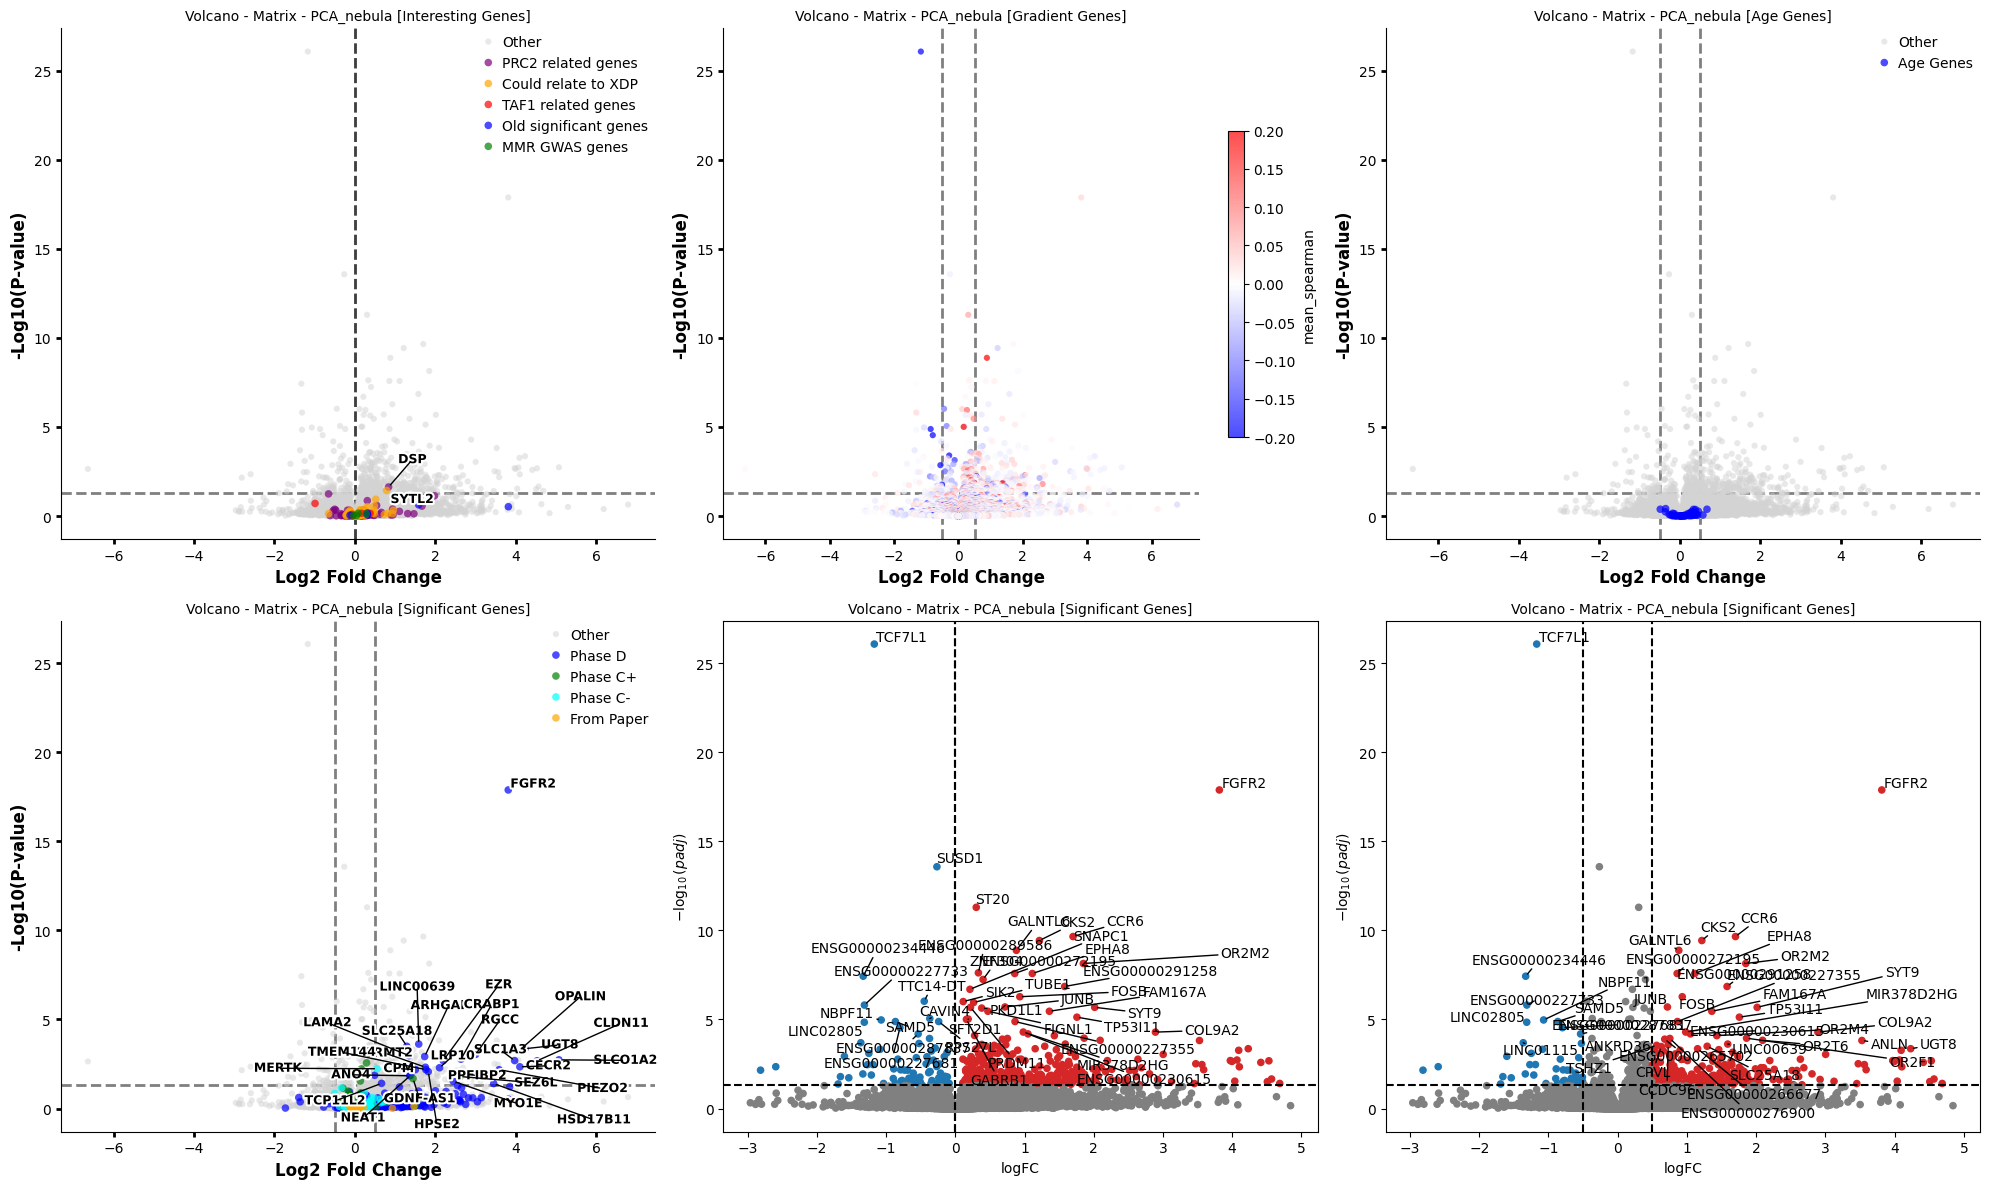

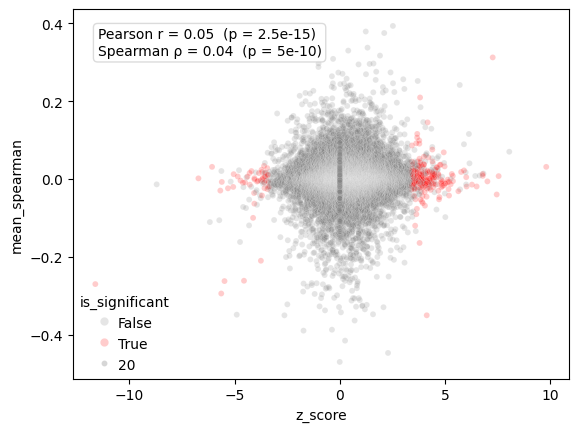

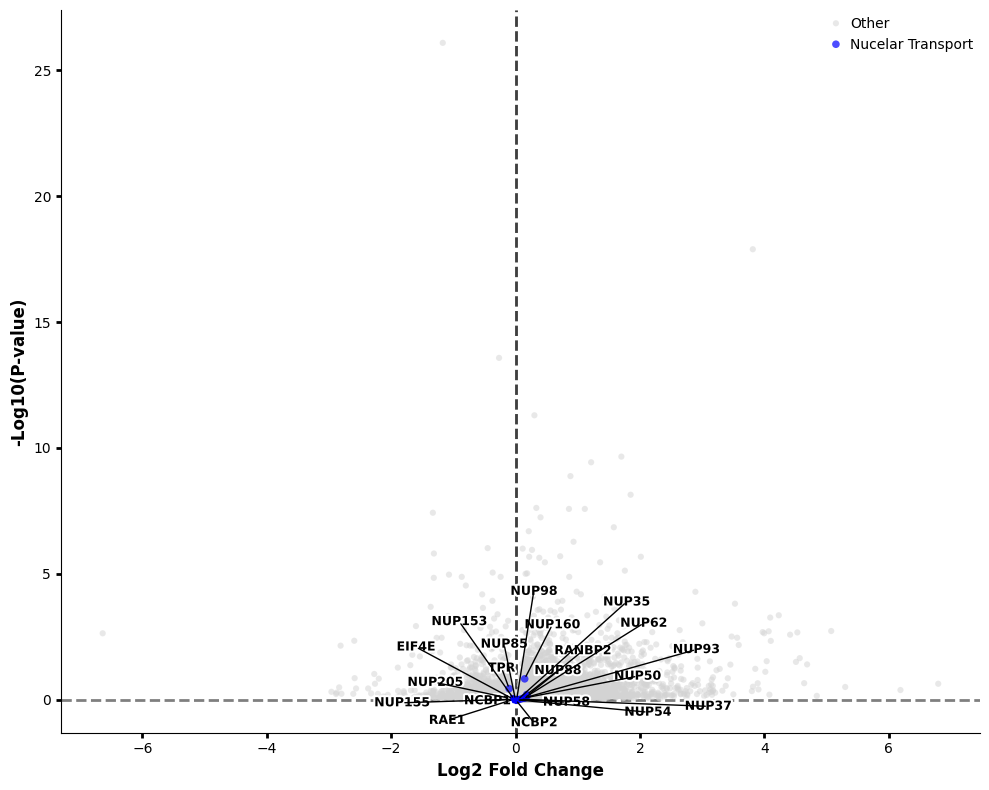


######################
 Patch 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Patch/deg_results.csv
ERROR: Missing results file for Patch at /home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG/PCA_nebula/Patch/deg_results.csv


In [10]:
import shutil

for SAVE_RESULT, ct in _all_results:

    print("\n######################\n", ct, "\n######################\n")

    save_csv_path = f"{SAVE_RESULT}/deg_results.csv"
    print(save_csv_path)

    img_dir = os.path.join(SAVE_RESULT, "images")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)
    os.makedirs(img_dir, exist_ok=True)

    formatted_save_csv_path = f"{SAVE_RESULT}/deg_results_formatted.csv"
    vulcano_plot_path = f"{img_dir}/volcano_plot.png"
    vulcano_plot_only_sig_path = f"{img_dir}/volcano_plot_only_sig.png"
    vulcano_plot_only_interesting_path = f"{img_dir}/volcano_plot_only_interesting.png"

    if not os.path.exists(save_csv_path):
        print(f"ERROR: Missing results file for {ct} at {save_csv_path}")
        continue

    df_nebula = pd.read_csv(save_csv_path)

    # ATTENTION: before changing logFC scale
    df_nebula["z_score"] = df_nebula[LOGFC_COL] / df_nebula[SE_COL]  # Wald z

    df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])
    df_nebula[LOGFC_COL] = df_nebula[LOGFC_COL] / np.log(2)  # ln -> log2
    df_nebula[COL_P_ADJ] = multipletests(df_nebula[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]

    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        extreme_intercept = df_nebula["logFC_(Intercept)"] < -20
        print(f"  Removing {extreme_intercept.sum()} genes with extreme intercept logFC")
        df_nebula = df_nebula[~extreme_intercept]

    df_nebula = df_nebula.merge(df_grad, how="left", left_on=GENE_COL, right_index=True)
    df_nebula = df_nebula.rename(columns={"is_gradient_gene": "is_grad_gene"})
    df_nebula = df_nebula.sort_values(COL_P_ADJ)

    sig_genes = df_nebula[(np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[COL_P_ADJ] <= PVAL_THR)][GENE_COL].tolist()
    df_sig = df_nebula[df_nebula[GENE_COL].isin(sig_genes)].copy()
    df_sig = df_sig[[GENE_COL, LOGFC_COL, COL_P_ADJ, "is_grad_gene", "mean_spearman"]]

    df_nebula_formatted = df_nebula[[GENE_COL, LOGFC_COL, PVAL_COL, "logFC_(Intercept)", "is_grad_gene", "mean_spearman"]].copy()
    df_nebula_formatted["is_significant"] = df_nebula_formatted[GENE_COL].isin(sig_genes)
    df_nebula_formatted.to_csv(formatted_save_csv_path, index=False)

    #########
    ### VOLCANO PLOT
    ##########
    categories_spatial = {"Spatial Gradient Genes": (grad_genes, "green")}
    categories_age = {"Age Genes": (["HCN1", "VWC2", "OPRM1", "BACH2", "PCED1B", "MME", "EBF1", "SPON1", "SEMA3E", "SERPINE2", "LINGO2", "GRM8", "KCNK2", "SINHCAF", "DDIT4L", "PTPN7", "PRKD1", "PEX5L", "OPCML", "SHC3", "PDE4B", "SLC24A2", "CCDC39", "FAT2", "CNTN5", "FIGN", "PTPRT", "MGAT4C", "IGF2BP2", "AR", "ETV1", "CDH10", "CORO1C", "SPRED2", "GJD2-DT", "ST3GAL6", "EPHA3", "UBASH3B", "PLEKHA7", "PLD5", "SH3RF3", "DOK5", "DOCK10", "SEMA3D", "KITLG", "SCN11A", "COL19A1", "ZNF732", "UNC13C", "SATB1"], "blue")}
    categories_handsaker_phases = {
        "Phase D": (phase_d.Gene.to_list(), "blue"),
        "Phase C+": (phase_c_plus.Gene.to_list(), "green"),
        "Phase C-": (phase_c_minus.Gene.to_list(), "cyan"),
        "From Paper": (["PDE10A", "PPP2R2B", "PPP3CA", "PHACTR1", "RYR3", "KCNA4", "KCNAB1", "KCND2", "KCNH1", "KCNK1", "KCNQ5", "KCTD1", "HOXA", "HOXB", "HOXC", "HOXD", "HOTAIR", "HOTTIP", "HOTAIRM1", "FOXD1", "LHX9", "ONECUT1", "POU4F2", "SHOX2", "SIX1", "TBX5", "TLX2", "ZIC4", "SLC17A6", "SLC17A7", "SLC6A5", "SLC1A2", "CALB2", "KCNC2", "CDKN2A", "CDKN2B"], "orange"),
    }
    categories_general = {
        "TAF1 related genes": (["TAF1", "TIA1", "ZNF772", "SMG7", "ZNF93", "MOV10L1", "EXO1", "SSH", "GLIA1", "OGT", "GLI3"], "red"),
        "MMR GWAS genes": (["FAN1", "MLH1", "MSH3", "PMS1", "PMS2", "LIG1"], "green"),
        "Old significant genes": (["SLC7A2", "FKBP5", "ZBTB16", "HIF3A", "NR3C1"], "blue"),
        "PRC2 related genes": ([
            'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
            'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
            'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', '4933436C20RIK', 'LECT1', 'ALDH1A7',
            'PYGL', 'DMRT3', 'TFAP2C', 'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1',
            'AMN', 'TMEM30B', 'IRX3', 'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3',
            'SIX6', 'COX6B2', 'TBX2', 'CD44', 'ASB4', 'PTPLAD2', 'SCARF2', 'VGLL2',
            'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10', 'HOXA9', 'HOXC10', 'SLC6A5',
            'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9', 'HOXB7', 'HOXB8', 'MNX1',
            'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2', 'LUM', 'GATA2', 'PMAIP1',
            'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1', 'FOXL2OS', 'HMX1', 'TBX3',
            'FOXA1', 'EBF3', 'SIM1', '1500016L03RIK', 'HOXB13', 'EN1', 'SERPINA3N',
            'RGNEF', 'HOXD13', 'LHX5', 'HOXA7', 'BC061194', 'HOXC5', 'NEUROD1', 'TFAP2A',
            'HOXB5', 'SHOX2', 'TFAP2B', 'NEUROD2', '2610027K06RIK', 'TLX1', 'TNNT2',
            'SULT1A1', 'VAX2', '1500011B03RIK', 'RPRD2', 'HOXD11', 'CDKN1A', 'NEUROG2',
            'EOMES', 'PLIN4', 'TPBG', '4930447C04RIK', 'SSTR3', 'DLK1', 'PRDM8',
            'E030030I06RIK', 'CES1D', 'HOXA4', 'NRN1', 'VSX2', 'AI448005', 'GFI1',
            'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2', 'MATN2', 'HOXB3', 'KRT1',
            'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2', 'HEYL', 'GSTA3', 'NKX2-5',
            'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4', 'C130021I20RIK', 'SIX1', 'GRP',
            'COL23A1', 'CIRBP', 'A030001D16RIK', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
            'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'UGT1A1', 'UGT1A10', 'UGT1A2', 'UGT1A5',
            'UGT1A6A', 'UGT1A6B', 'UGT1A7C', 'UTG1A9', 'ISLR', 'ASB5', 'MYCL1',
            'TRP53I11', 'SDC1', '9530018H14RIK', 'GATA4', 'BEND5', 'GM15453', 'RBM3',
            'FXYD7', 'FOXL2', '1700109F18RIK', 'GM8350', 'ZFP644', '4933439C10RIK',
            'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25', 'CLDN3', 'SLC6A7', 'SERPINB1B',
            'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD', 'GALNTL1', 'GNA13', 'ALX1',
            'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1', 'CPA6', 'DMRT2',
            'CPNE6', '9330171B17RIK', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
            'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2'
        ], "purple"),
        "Could relate to XDP": ([
            "TAF1", "OGT", "OGA", "ACRC", "CXCR3", "NONO", "ING2", "NLGN3", "GJB1", "ZNF261", "ITGB1BP2",
            "TBP", "TAF2", "TAF3", "TAF4", "TAF5", "TAF6", "TAF7", "TAF8", "TAF9", "TAF10", "TAF11", "TAF12", "TAF13",
            "TP53", "MDM2", "RB1", "AR", "JUN", "CCND1", "CCNA2",
            "GTF2B", "GTF2A1", "GTF2A2", "GTF2E1", "GTF2E2", "GTF2F1", "GTF2F2", "GTF2H1", "GTF2H2", "GTF2H3", "GTF2H4", "GTF2H5", "TCEA1", "ERCC2", "ERCC3",
            "KMT2A", "ASH2L", "HCFC1", "WDR5", "RBBP5",
            "DRD2", "DRD1", "PDE10A", "GNAL",
            "SYP", "SNAP25", "RAB26", "RAB27B", "RAB8B", "DDC", "GCH1", "SLC18A2", "SYT7", "DLG4", "SNAP91", "DBH", "SYTL2", "SLC5A3", "EFNB1",
            "RELA", "NFKB1", "NFKB2", "IKBKB", "IKBKG", "TNFAIP6", "IL8",
            "MSH3", "PMS2",
            "SRSF2", "DHX15", "DHX9", "FUS", "GEMIN5", "HRNPU", "NOVA1", "PAPOLA", "PRPF6", "SART3", "SRSF5", "RALY", "U2AF1L5",
            "BMS1", "TRMT5",
            "ZNF91", "TRIM28", "ZNF93", "SETDB1", "DNMT3A", "DNMT3B",
            "L1RE1",
            "UPF1", "UPF2", "UPF3B",
            "KMT5C", "CIITA",
            "TAF1L"
        ], "orange"),
    }

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 12))

    DEG.plot_vulcano(df_nebula, logfc_col=LOGFC_COL, pval_col=COL_P_ADJ, gene_col=GENE_COL,
                      pval_thresh=PVAL_THR, logfc_thresh=0, to_label=0,
                      categories=categories_general, max_y=None, ax=ax1)

    DEG.plot_vulcano(df_nebula, logfc_col=LOGFC_COL, pval_col=COL_P_ADJ, gene_col=GENE_COL,
                      pval_thresh=PVAL_THR, logfc_thresh=LOGFC_THR, to_label=0,
                      color_by="mean_spearman", cmap="bwr", vmin=-0.2, vmax=0.2,
                      max_y=None, ax=ax2, print_labels=False)

    DEG.plot_vulcano(df_nebula, logfc_col=LOGFC_COL, pval_col=COL_P_ADJ, gene_col=GENE_COL,
                      pval_thresh=PVAL_THR, logfc_thresh=LOGFC_THR, to_label=0,
                      categories=categories_age, max_y=None, ax=ax3, print_labels=True)

    DEG.plot_vulcano(df_nebula, logfc_col=LOGFC_COL, pval_col=COL_P_ADJ, gene_col=GENE_COL,
                      pval_thresh=PVAL_THR, logfc_thresh=LOGFC_THR, to_label=0,
                      categories=categories_handsaker_phases, max_y=None, ax=ax4, print_labels=True)

    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}),
        x="logFC", y="padj", top=40, thr_stat=1e-20, thr_sign=PVAL_THR, max_stat=5, ax=ax5,
    )
    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}),
        x="logFC", y="padj", top=40, thr_stat=LOGFC_THR, thr_sign=PVAL_THR, max_stat=5, ax=ax6,
    )

    title = f"Volcano - {ct} - {TYPE_DEG}"
    for ax, lbl in zip([ax1, ax2, ax3, ax4, ax5, ax6],
                        ["Interesting Genes", "Gradient Genes", "Age Genes", "Significant Genes", "Significant Genes", "Significant Genes"]):
        ax.set_title(f"{title} [{lbl}]", fontsize=10)

    plt.tight_layout()
    plt.savefig(vulcano_plot_path, dpi=150, bbox_inches="tight")

    extent = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_interesting_path, bbox_inches=extent, dpi=150)
    extent = ax6.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_sig_path, bbox_inches=extent, dpi=150)
    plt.show()

    ####
    # scatterplot correlation
    df_nebula["is_significant"] = df_nebula[GENE_COL].isin(sig_genes)
    from scipy.stats import pearsonr, spearmanr
    ax_scat = sns.scatterplot(data=df_nebula, x="z_score", y="mean_spearman", hue="is_significant", palette={True: "red", False: "grey"}, alpha=0.2, size=20)
    d = df_nebula[["mean_spearman", "z_score"]].dropna()
    r_p, p_p = pearsonr(d["mean_spearman"], d["z_score"])
    r_s, p_s = spearmanr(d["mean_spearman"], d["z_score"])
    ax_scat.text(0.05, 0.95, f"Pearson r = {r_p:.2f}  (p = {p_p:.2g})\nSpearman \u03c1 = {r_s:.2f}  (p = {p_s:.2g})",
                 transform=ax_scat.transAxes, va="top", ha="left", fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgrey", alpha=0.8))
    plt.show()

    DEG.plot_vulcano(
        df_nebula, logfc_col=LOGFC_COL, pval_col=COL_P_ADJ, gene_col=GENE_COL,
        pval_thresh=1, logfc_thresh=0, to_label=0,
        categories={"Nucelar Transport": (["NUP155", "NUP58", "NUP160", "NUP93", "NUP88", "NUP54", "TPR", "NUP37", "RANBP2", "NUP153", "EIF4E", "NUP50", "RAE1", "NCBP2", "NCBP1", "NUP98", "NUP85", "NUP35", "NUP205", "NUP62"], "blue")},
        max_y=None, print_labels=True,
    ); plt.show()

# Make summary csv

Saves to `.../DEG/{TYPE_DEG}/_summary/all_results.csv`
(no `by_zone`/`by_zone_4` split - no zone-loop Run section for SlideTags).

Columns: `cell_type` (folder label) - `gene` - `log2FC` - `adj_pvalue` (fdr_bh) - `raw_pvalue`

In [ ]:
BASE = RESULTS_FOLDER
OUT = os.path.join(BASE, "_summary")
if os.path.exists(OUT):
    shutil.rmtree(OUT)
os.makedirs(OUT, exist_ok=True)

def read_ct(csv_path, cell_type_label):
    df = pd.read_csv(csv_path).dropna(subset=[PVAL_COL, LOGFC_COL])
    df[LOGFC_COL] = df[LOGFC_COL] / np.log(2)  # ln -> log2
    df["adj_pvalue"] = multipletests(df[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]

    df = pd.DataFrame({
        "cell_type": cell_type_label,
        "gene": df["gene"],
        "log2FC": df[LOGFC_COL],
        "raw_pvalue": df[PVAL_COL],
        "adj_pvalue": df["adj_pvalue"],
        "signed_neg_log10_p": -np.log10(df["adj_pvalue"]) * np.sign(df[LOGFC_COL]),
        "logFC_intercept": df["logFC_(Intercept)"],
    })
    df = df.merge(df_grad[["mean_spearman", "p-value_gradient", "is_gradient_gene"]], how="left", left_on="gene", right_index=True)
    return df

all_dfs = []
for SAVE_RESULT, label in _all_results:
    csv = os.path.join(SAVE_RESULT, "deg_results.csv")
    if os.path.isfile(csv):
        all_dfs.append(read_ct(csv, label))

if all_dfs:
    out_path = os.path.join(OUT, "all_results.csv")
    pd.concat(all_dfs, ignore_index=True).to_csv(out_path, index=False)
    print(f"Saved all_results.csv ({len(all_dfs)} result blocks) -> {out_path}")

    df_all = pd.read_csv(out_path)
    sig = df_all[(df_all["adj_pvalue"] <= PVAL_THR) & (df_all["log2FC"].abs() >= LOGFC_THR)]
    gene_ct_count = sig.groupby("gene")["cell_type"].nunique().sort_values(ascending=False)
    print(gene_ct_count.head(30))  # genes significant across the most result blocks

# GSEA on DEGs genes

In [ ]:
# which gseapy libraries are available (reference only)
gp.get_library_name()

In [ ]:
# Homemade genesets
custom_gene_sets = {
    "Gradient_DorsalVentral": grad_genes,
    "Gradient_Dorsal": df_grad[(df_grad.mean_spearman < 0) & (df_grad.is_gradient_gene)].index.tolist(),
    "Gradient_Ventral": df_grad[(df_grad.mean_spearman > 0) & (df_grad.is_gradient_gene)].index.tolist(),
    "PhaseD_genes": phase_d["Gene"].dropna().tolist(),
    "PhaseC+_genes": phase_c_plus["Gene"].dropna().tolist(),
    "PhaseC-_genes": phase_c_minus["Gene"].dropna().tolist(),
    "polycomb": lmu.prc2_genes,
    "mix_handsaker": lmu.handsaker_genes,
    "xdp_related": lmu.xdp_genes,
}
print({k: len(v) for k, v in custom_gene_sets.items()})

In [ ]:
collections_gsea = [
    ("custom", custom_gene_sets, custom_gene_sets, 1, 5000),
    ("MSigDB_Hallmark_2020", ["MSigDB_Hallmark_2020"], gp.get_library("MSigDB_Hallmark_2020"), 15, 250),
    ("SynGO_2024", ["SynGO_2024"], gp.get_library("SynGO_2024"), 15, 250),
    ("Reactome_Pathways_2024", ["Reactome_Pathways_2024"], gp.get_library("Reactome_Pathways_2024"), 15, 250),
    ("GO_Biological_Process_2025", ["GO_Biological_Process_2025"], gp.get_library("GO_Biological_Process_2025"), 15, 250),
    ("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X", ["ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X"], gp.get_library("ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X"), 15, 250),
    ("TRRUST_Transcription_Factors_2019", ["TRRUST_Transcription_Factors_2019"], gp.get_library("TRRUST_Transcription_Factors_2019"), 15, 250),
]

In [ ]:
def filter_noisy_genes(ranked_series, verbose=True):
    import re
    n_before = len(ranked_series)
    _pattern = re.compile(r'''^(
        RPL   | RPS   | MRPL  | MRPS  |
        MT-                            |
        LINC                           |
        SNHG  | SNORA | SNORD          |
        MIR[0-9]                       |
        RNU                            |
        ENSG
    )''', re.IGNORECASE | re.VERBOSE)

    noisy = [g for g in ranked_series.index if _pattern.match(g)]
    ranked_series = ranked_series.drop(index=noisy)

    n_removed = n_before - len(ranked_series)
    if verbose:
        print(f"  filter_noisy_genes: removed {n_removed} genes  ({n_before} -> {len(ranked_series)} remaining)")
    return ranked_series


def from_deg_df_to_df_rank(df, GENE_COL, PVAL_COL=None, LOGFC_COL=None, score_col=None, REMOVE_GENE_TOO_HIGH_INTERCEPT=True, REMOVE_RIBO_GENES_FROM_GSEA=True, intercept_logfc_col="logFC_(Intercept)"):
    df_rank = df.copy()

    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        extreme_intercept = df_rank[intercept_logfc_col] < -20
        print(f"  [filter] Removed {extreme_intercept.sum()} genes with extreme intercept logFC (< -20)")
        df_rank = df_rank[~extreme_intercept]

    if score_col is None:
        if PVAL_COL is None or LOGFC_COL is None:
            raise ValueError("Must provide either score_col or both PVAL_COL and LOGFC_COL")

        df_rank = df_rank.dropna(subset=[PVAL_COL, LOGFC_COL])

        # ATTENTION: use raw p-values - GSEA does its own permutation-based multiple testing
        df_rank["rank_metric"] = (
            np.sign(df_rank[LOGFC_COL]) *
            -np.log10(df_rank[PVAL_COL].clip(lower=1e-300))
        )
    else:
        if score_col not in df_rank.columns:
            raise ValueError(f"score_col '{score_col}' not found in DataFrame")
        df_rank["rank_metric"] = df_rank[score_col]

    sns.histplot(df_rank["rank_metric"], bins=100); plt.show()

    df_rank = df_rank.sort_values("rank_metric", ascending=False)
    ranked_series = df_rank.set_index(GENE_COL)["rank_metric"]

    if REMOVE_RIBO_GENES_FROM_GSEA:
        ranked_series = filter_noisy_genes(ranked_series, verbose=True)
        surviving_genes = ranked_series.index
        df_rank = df_rank[df_rank[GENE_COL].isin(surviving_genes)]

    return ranked_series, df_rank

In [ ]:
THR_FDR_GSEA = 0.05
THR_FDR_ORA = 0.05
THR_FDR_DEG = 0.05
THR_LOGFC = 0.50

for SAVE_RESULT, ct in _all_results:

    print(f"\n{'='*60}\n  RESULT: {ct}\n{'='*60}")

    save_csv_path = f"{SAVE_RESULT}/deg_results.csv"

    if not os.path.exists(save_csv_path):
        print(f"  [ERROR] Missing results file: {save_csv_path}")
        continue

    img_dir = os.path.join(SAVE_RESULT, "gsea_on_degs")
    if os.path.exists(img_dir):
        shutil.rmtree(img_dir)
    os.makedirs(img_dir, exist_ok=True)

    df_nebula = pd.read_csv(save_csv_path)
    df_nebula["z_score"] = df_nebula[LOGFC_COL] / df_nebula[SE_COL]
    df_nebula[LOGFC_COL] = df_nebula[LOGFC_COL] / np.log(2)

    display(df_nebula); plt.show()
    display(sns.histplot(df_nebula, x=PVAL_COL)); plt.show()

    ranked_series, df_rank = from_deg_df_to_df_rank(
        df_nebula, GENE_COL=GENE_COL, PVAL_COL=PVAL_COL, LOGFC_COL=LOGFC_COL,
        REMOVE_GENE_TOO_HIGH_INTERCEPT=REMOVE_GENE_TOO_HIGH_INTERCEPT,
        REMOVE_RIBO_GENES_FROM_GSEA=REMOVE_RIBO_GENES_FROM_GSEA, score_col=None,
    )

    print(f"  [rank]   {len(ranked_series)} genes in final ranked list (top: {ranked_series.index[0]} {ranked_series.iloc[0]:+.2f}, bottom: {ranked_series.index[-1]} {ranked_series.iloc[-1]:+.2f})")
    display(ranked_series)

    for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:
        try:
            print(f"\n  {'-'*50}\n  GSEA  \u25b6  {db_name}\n  {'-'*50}")

            pre_res = gp.prerank(
                rnk=ranked_series, gene_sets=gene_sets, seed=42, permutation_num=1000,
                min_size=min_s, max_size=max_s, verbose=False, threads=30,
            )

            df_gsea = pre_res.res2d.copy().sort_values("FDR q-val")
            df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA].copy()

            df_gsea.to_csv(f"{img_dir}/{db_name}_gsea_all.csv", index=False)
            df_gsea_sig.to_csv(f"{img_dir}/{db_name}_gsea_sig.csv", index=False)

            print(f"  [result] {len(df_gsea)} pathways tested  ->  {len(df_gsea_sig)} significant (FDR <= {THR_FDR_GSEA})")

            with pd.option_context('display.max_colwidth', None):
                display(df_gsea_sig[["Term", "NES", "FDR q-val", "Lead_genes"]])

            if len(df_gsea_sig) == 0:
                print(f"  [plot]   Skipping dotplot - no significant terms")
            else:
                try:
                    res2d_plot = df_gsea.copy()
                    res2d_plot["FDR q-val"] = res2d_plot["FDR q-val"].replace(0, 1e-300)
                    dotplot(res2d_plot, column="FDR q-val", cmap=plt.cm.viridis, size=6,
                            figsize=(10, 10), cutoff=THR_FDR_GSEA, show_ring=False, ofname=None,
                            top_term=len(df_gsea_sig))
                    plt.title(f"{ct} / {db_name}")
                    plt.savefig(f"{img_dir}/{db_name}_dotplot.png", dpi=150, bbox_inches="tight")
                    plt.show(); plt.close()
                except Exception as plot_err:
                    print(f"  [plot]   Dotplot failed ({plot_err}), results already saved to CSV")

            #######################
            ### Leading Edge Analysis
            #######################
            print(f"\n  [leading edge]  {db_name}")

            df_gsea_sig["lead_genes"] = (
                df_gsea_sig["Lead_genes"].str.split(";")
                .apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])
            )
            df_gsea_sig["n_lead"] = df_gsea_sig["lead_genes"].apply(len)

            gene_freq = Counter(g for genes in df_gsea_sig["lead_genes"] for g in genes)
            df_gene_freq = pd.DataFrame(gene_freq.most_common(), columns=["gene", "n_pathways"])
            print(f"  [leading edge]  genes in >=2 pathways: {(df_gene_freq['n_pathways'] > 1).sum()}")
            display(df_gene_freq[df_gene_freq["n_pathways"] > 1])
            df_gene_freq.to_csv(f"{img_dir}/{db_name}_leading_edge_freq.csv", index=False)

            recurring_genes = df_gene_freq[df_gene_freq["n_pathways"] > 1]["gene"].tolist()

            if not recurring_genes:
                print("  [leading edge]  No recurring genes - skipping heatmap")
            else:
                gene_order = (
                    df_rank.set_index(GENE_COL)["rank_metric"]
                    .loc[lambda s: s.index.isin(recurring_genes)]
                    .sort_values(ascending=False).index.tolist()
                )

                matrix = pd.DataFrame(np.nan, index=df_gsea_sig["Term"], columns=gene_order)
                for _, row in df_gsea_sig.iterrows():
                    for gene in set(row["lead_genes"]) & set(gene_order):
                        matrix.loc[row["Term"], gene] = df_rank.set_index(GENE_COL).loc[gene, LOGFC_COL]

                vmax = np.nanmax(np.abs(matrix.values))
                fig, ax = plt.subplots(figsize=(max(8, len(gene_order) * 0.45), max(3, len(matrix) * 0.5)))
                sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                            linewidths=0.5, linecolor="lightgrey",
                            cbar_kws={"label": "log2FC", "shrink": 0.6}, ax=ax)
                ax.set_title(f"Leading Edge - {ct} / {db_name}")
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
                ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
                plt.tight_layout()
                plt.savefig(f"{img_dir}/{db_name}_leading_edge_heatmap.png", dpi=150, bbox_inches="tight")
                plt.show(); plt.close(fig)

                # ── Collapsed heatmap: cluster redundant pathways by leading-edge Jaccard ──
                from scipy.cluster.hierarchy import linkage, fcluster
                from scipy.spatial.distance import squareform

                JACCARD_DIST_CUTOFF = 0.3

                if len(df_gsea_sig) < 2:
                    print("  [collapsed]  <2 pathways - nothing to collapse")
                else:
                    lead_sets = [set(g) for g in df_gsea_sig["lead_genes"]]
                    n = len(lead_sets)
                    dist = np.zeros((n, n))
                    for a in range(n):
                        for b in range(a + 1, n):
                            u = len(lead_sets[a] | lead_sets[b])
                            dist[a, b] = dist[b, a] = 1 - len(lead_sets[a] & lead_sets[b]) / u if u else 1.0

                    clusters = fcluster(linkage(squareform(dist), method="average"), t=JACCARD_DIST_CUTOFF, criterion="distance")
                    df_gsea_sig = df_gsea_sig.assign(cluster=clusters)

                    reps = (df_gsea_sig
                            .sort_values(["FDR q-val", "NES"], key=lambda s: s.abs() if s.name == "NES" else s, ascending=[True, False])
                            .groupby("cluster", as_index=False).first())

                    sizes = df_gsea_sig.groupby("cluster").size()
                    reps["Term"] = reps.apply(lambda r: f"{r['Term']}  (+{sizes[r['cluster']]-1})" if sizes[r['cluster']] > 1 else r["Term"], axis=1)

                    print(f"  [collapsed]  {len(df_gsea_sig)} pathways -> {len(reps)} clusters")

                    rep_gene_freq = Counter(g for genes in reps["lead_genes"] for g in genes)
                    rec_genes = [g for g, n in rep_gene_freq.items() if n > 1]

                    if not rec_genes:
                        print("  [collapsed]  No recurring genes after collapsing - skipping heatmap")
                    else:
                        logfc = df_rank.set_index(GENE_COL)[LOGFC_COL]
                        gene_order = logfc.loc[logfc.index.isin(rec_genes)].sort_values(ascending=False).index.tolist()

                        matrix = pd.DataFrame(np.nan, index=reps["Term"], columns=gene_order)
                        for _, row in reps.iterrows():
                            for g in set(row["lead_genes"]) & set(gene_order):
                                matrix.loc[row["Term"], g] = logfc[g]

                        matrix.index = [t if len(t) < 60 else t[:57] + "..." for t in matrix.index]

                        vmax = np.nanmax(np.abs(matrix.values))
                        fig, ax = plt.subplots(figsize=(max(8, len(gene_order) * 0.45), max(3, len(matrix) * 0.5)))
                        sns.heatmap(matrix, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                                    linewidths=0, cbar_kws={"label": "log2FC", "shrink": 0.6}, ax=ax)
                        ax.set_title(f"Leading Edge (collapsed, Jaccard <= {JACCARD_DIST_CUTOFF}) - {ct} / {db_name}")
                        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
                        ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
                        plt.tight_layout()
                        plt.show(); plt.close(fig)

        except Exception as e:
            print(f"  [ERROR]  GSEA failed for {ct} / {db_name}: {e}")

    # #########
    # ### ORA - Over-Representation Analysis (fully local), disabled by default (same as
    # ### NucSeq_DEG_interpretation.ipynb) - uncomment to enable.
    # ##########
    # print(f"\n  {'='*50}\n  ORA  \u25b6  {ct}\n  {'='*50}")
    # ora_dir = os.path.join(SAVE_RESULT, "ora_on_degs")
    # if os.path.exists(ora_dir): shutil.rmtree(ora_dir)
    # os.makedirs(ora_dir)
    # background = ranked_series.index.tolist()
    # df_rank["adj_pvalue"] = multipletests(df_rank[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]
    # df_bg = df_rank[df_rank[GENE_COL].isin(background)]
    # sig_up = df_bg[(df_bg["adj_pvalue"] <= THR_FDR_DEG) & (df_bg[LOGFC_COL] > THR_LOGFC)][GENE_COL].tolist()
    # sig_down = df_bg[(df_bg["adj_pvalue"] <= THR_FDR_DEG) & (df_bg[LOGFC_COL] < -THR_LOGFC)][GENE_COL].tolist()
    # print(f"  [DEGs]   {len(sig_up)} up  |  {len(sig_down)} down  |  background: {len(background)} genes")
    # for direction, gene_list in [("up", sig_up), ("down", sig_down)]:
    #     if len(gene_list) < 5:
    #         print(f"  [ORA {direction}]  Too few DEGs ({len(gene_list)} < 5) - skipping"); continue
    #     for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:
    #         try:
    #             enr = gp.enrich(gene_list=gene_list, gene_sets=gs_dict, background=background, outdir=None, no_plot=True, verbose=False)
    #             df_ora = enr.res2d.sort_values("Adjusted P-value")
    #             df_ora_sig = df_ora[df_ora["Adjusted P-value"] <= THR_FDR_ORA]
    #             df_ora.to_csv(f"{ora_dir}/ORA_{direction}_{db_name}_all.csv", index=False)
    #             df_ora_sig.to_csv(f"{ora_dir}/ORA_{direction}_{db_name}_sig.csv", index=False)
    #             print(f"  [ORA {direction}]  {db_name}:  {len(df_ora)} tested  ->  {len(df_ora_sig)} significant (FDR <= {THR_FDR_ORA})")
    #         except Exception as e:
    #             print(f"  [ERROR]  ORA {direction} / {db_name} failed: {e}")

# GSEA on Factors

In [ ]:
small_curated_pathways = {
    "Oligodendrocyte_WM": ["OPALIN"],
    "Oligodendrocyte_GM": ["PLEKHG1"],
    "Oligodendrocyte_Reactive": ["FRY", "BCAS1", "HSPA1A"],
    "Oligodendrocyte_Cortisol": ["FKBP5", "TSC22D3", "SGK1"],

    "Astrocyte_WM": ["GFAP", "CRYAB", "VIM"],
    "Astrocyte_GM": ["SLC1A2", "SLC1A3", "GJA1", "ALDH1L1"],
    "Astrocyte_A1_Reactive": ["C3", "SERPING1", "SERPINA3", "GBP2", "SRGN", "AMIGO2"],
    "Astrocyte_A2_Antiinflammatory": ["S100A10", "PTX3", "EMP1", "CD14", "SPHK1"],
    "Astrocyte_Cortisol": ["FKBP5", "TSC22D3", "SGK1"],

    "Microglia_Homeostatic": ["CX3CR1", "P2RY12", "TMEM119", "HEXB", "CSF1R"],
    "Microglia_DAM": ["GPNMB", "TREM2", "SPP1", "LPL", "CD9", "APOE"],

    "General_Mito": ["MT-CO1", "MT-CO2", "MT-ND1", "MT-ND3", "MT-ATP6", "MT-CYB"],
    "General_Housekeeping": ["GAPDH", "ACTB", "B2M"],
    "General_Cortisol": ["FKBP5", "TSC22D3", "SGK1", "PER1", "ZBTB16"],
    "General_Hypoxia": ["HIF1A", "VEGFA", "LDHA", "SLC2A1"],
    "General_Stress_HSP": ["HSPA1A", "HSPA1B", "HSPB1", "HSP90AA1", "DNAJB1"],
    "General_CellCycle": ["MKI67", "CENPA", "TOP2A", "PCNA", "CDK1", "MCM2"],
    "General_lncRNA": ["MALAT1", "NEAT1", "XIST"],
    "General_ImmediateEarlyGenes": ["FOS", "JUN", "ARC", "FOSB", "JUNB", "EGR1", "NPAS4"],

    "Oligodendrocyte_Markers": ["MOG", "OLIG1", "OPALIN", "MBP", "PLP1", "CNP", "LGALS1", "PALM2"],
    "Astrocyte_Markers": ["GFAP", "AQP4", "ALDH1L1", "S100B", "SOX9", "SLC1A2"],
    "Microglia_Markers": ["C1QA", "C1QB", "CX3CR1", "P2RY12", "TREM2", "TMEM119", "AIF1", "CSF1R", "HEXB"],

    "Striosome_Markers": ["OPRM1", "FOXP2", "TSHZ1"],
    "Matrix_Markers": ["CALB1", "EBF1"],
}

In [ ]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="gseapy")

In [ ]:
# Only meaningful for factor-based TYPE_DEG values. SlideTags_DEG_factors.ipynb writes
# gene_loadings.csv via the same shared nebula_with_factors.calculate_pca() as NucSeq, so the
# PCA_nebula branch works unchanged; cNMF_nebula isn't offered as a TYPE_DEG here (no UGER
# factorization pipeline wired up for SlideTags) so that branch is dead code kept for parity.
if TYPE_DEG in ["PCA_nebula", "cNMF_nebula"]:

    THR_FDR_GSEA = 0.05

    for SAVE_RESULT, ct in _all_results:

        print(f"\n{'='*60}\n  RESULT: {ct}\n{'='*60}")

        if TYPE_DEG == "PCA_nebula":
            matrix_path = f"{SAVE_RESULT}/gene_loadings.csv"
            if not os.path.exists(matrix_path):
                print(f"  [ERROR] Missing gene_loadings.csv for {ct}, skipping")
                continue
            df_matrix = pd.read_csv(matrix_path, index_col=0)
            factor_cols = df_matrix.columns.tolist()

        elif TYPE_DEG == "cNMF_nebula":
            score_files = glob.glob(f"{SAVE_RESULT}/cNMF_run_healthy/*.gene_spectra_score.*.txt")
            if not score_files:
                print(f"  [ERROR] No gene_spectra_score file found for {ct}, skipping")
                continue
            df_matrix = pd.read_csv(score_files[0], sep="\t", index_col=0).T
            df_matrix.columns = [f"GEP_{i+1}" for i in range(df_matrix.shape[1])]
            factor_cols = df_matrix.columns.tolist()

        symbol_mask = ~df_matrix.index.str.startswith("ENSG")
        df_matrix = df_matrix[symbol_mask]

        display(df_matrix.head())

        img_dir = os.path.join(SAVE_RESULT, "factors_investigation", "gsea")
        if os.path.exists(img_dir):
            shutil.rmtree(img_dir)
        os.makedirs(img_dir, exist_ok=True)

        #########################
        # Save top and bottom genes per factor
        #########################
        N_GENES = 30
        data = {"rank": list(range(1, N_GENES + 1))}

        for factor in factor_cols:
            series = df_matrix[factor].dropna()
            top_genes = series.sort_values(ascending=False).head(N_GENES).index.tolist()
            bot_genes = series.sort_values(ascending=True).head(N_GENES).index.tolist()
            data[f"{factor}_pos"] = top_genes
            data[f"{factor}_neg"] = bot_genes

        df_genes = pd.DataFrame(data)
        save_path = os.path.join(SAVE_RESULT, f"{N_GENES}_top_genes_per_pc.csv")
        df_genes.to_csv(save_path, index=False)
        print(f"  [top genes] Saved top {N_GENES} positive and negative genes per factor to:\n    {save_path}")
        display(df_genes)

        #########################
        # Save argmax-specific genes per factor
        #########################
        argmax_gep = df_matrix.idxmax(axis=1)
        data_specific = {"rank": list(range(1, N_GENES + 1))}

        for factor in factor_cols:
            specific_gene_mask = argmax_gep == factor
            specific_genes = df_matrix.index[specific_gene_mask]
            top_specific = (
                df_matrix.loc[specific_genes, factor].sort_values(ascending=False).head(N_GENES).index.tolist()
            )
            top_specific += [""] * (N_GENES - len(top_specific))
            data_specific[factor] = top_specific

        df_specific = pd.DataFrame(data_specific)
        save_path_specific = os.path.join(SAVE_RESULT, f"{N_GENES}_specific_genes_per_gep.csv")
        df_specific.to_csv(save_path_specific, index=False)
        print(f"  [specific genes] Saved top {N_GENES} argmax-specific genes per GEP to:\n    {save_path_specific}")
        display(df_specific)

        #########################
        # GO - ORA via percentile threshold
        #########################
        PERCENTILE_THR = 99.5
        MIN_GENES_ORA = 10
        background_genes = df_matrix.index.tolist()

        for factor in factor_cols:
            gep_scores = df_matrix[factor].dropna()
            thr = gep_scores.quantile(PERCENTILE_THR / 100)
            gene_list = gep_scores[gep_scores > thr].sort_values(ascending=False).index.tolist()
            print(f"  [{factor}] Number of genes above the threshold:", len(gene_list))
            print(gene_list[:10])

            if len(gene_list) < MIN_GENES_ORA:
                print(f"  [{factor}] {len(gene_list)} genes < {MIN_GENES_ORA} - skipping")
                continue

            print(f"  [{factor}] {len(gene_list)} genes -> ORA")

            for coll_name, _, gs_dict, min_size, max_size in collections_gsea:
                try:
                    enr = gp.enrich(gene_list=gene_list, gene_sets=gs_dict, background=background_genes, outdir=None, verbose=False)
                    df_res = enr.results.copy()

                    if df_res.empty:
                        print(f"    [{coll_name}] Empty results")
                        continue

                    if "Overlap" in df_res.columns:
                        try:
                            gs_sizes = df_res["Overlap"].apply(lambda x: int(x.split("/")[1]))
                            df_res = df_res[gs_sizes.between(min_size, max_size)]
                        except Exception:
                            pass

                    df_sig = df_res[df_res["Adjusted P-value"] < THR_FDR_GSEA].sort_values("Adjusted P-value")

                    if df_sig.empty:
                        print(f"    [{coll_name}] No significant terms")
                        continue

                    df_sig.to_csv(os.path.join(img_dir, f"{factor}_{coll_name}_ORA.csv"), index=False)

                    try:
                        barplot(df_res, column="Adjusted P-value", group="Gene_set",
                                title=f"{ct} - {factor} - {coll_name}", cmap="viridis_r", top_term=10,
                                ofname=os.path.join(img_dir, f"{factor}_{coll_name}_barplot.pdf"))
                        plt.show(); plt.close()
                    except Exception as e:
                        print(f"    [{coll_name}] Plot failed: {e}")

                except Exception as e:
                    print(f"    [{coll_name}] ORA failed: {e}")

        # #########################
        # # GSEA ON FACTORS (prerank) + GSEA ON SMALL CURATED PATHWAYS - disabled by default,
        # # same as NucSeq_DEG_interpretation.ipynb. Uncomment to enable.
        # #########################
        # for factor in factor_cols:
        #     df_factor = df_matrix[[factor]].rename(columns={factor: "score"}).rename_axis(GENE_COL).reset_index()
        #     ranked_series, df_rank = from_deg_df_to_df_rank(df_factor, GENE_COL=GENE_COL, PVAL_COL=None, LOGFC_COL=None, score_col="score", REMOVE_GENE_TOO_HIGH_INTERCEPT=False, REMOVE_RIBO_GENES_FROM_GSEA=False)
        #     factor_dir = os.path.join(img_dir, factor)
        #     os.makedirs(factor_dir, exist_ok=True)
        #     for db_name, gene_sets, gs_dict, min_s, max_s in collections_gsea:
        #         try:
        #             pre_res = gp.prerank(rnk=ranked_series, gene_sets=gene_sets, score_type="std", seed=42, permutation_num=1000, min_size=min_s, max_size=max_s, verbose=False, threads=30)
        #             df_gsea = pre_res.res2d.copy().sort_values("FDR q-val")
        #             df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA].copy()
        #             df_gsea.to_csv(f"{factor_dir}/{db_name}_gsea_all.csv", index=False)
        #             df_gsea_sig.to_csv(f"{factor_dir}/{db_name}_gsea_sig.csv", index=False)
        #         except Exception as e:
        #             print(f"    [ERROR] GSEA failed for {factor} / {db_name}: {e}")
        #     from scipy.stats import mannwhitneyu
        #     factor_results = []
        #     for pathway_name, genes in small_curated_pathways.items():
        #         genes_found = [g for g in genes if g in ranked_series.index]
        #         if not genes_found:
        #             continue
        #         n = len(ranked_series)
        #         ranks = ranked_series.rank(ascending=False)
        #         in_set = ranked_series[ranked_series.index.isin(genes_found)]
        #         out_set = ranked_series[~ranked_series.index.isin(genes_found)]
        #         gene_ranks = ranks[genes_found]
        #         median_pct = round(gene_ranks.median() / n * 100, 2)
        #         mean_pct = round(gene_ranks.mean() / n * 100, 2)
        #         stat, pval = mannwhitneyu(in_set, out_set, alternative="two-sided", method="exact")
        #         auc = round(stat / (len(in_set) * len(out_set)), 3)
        #         factor_results.append({"factor": factor, "pathway": pathway_name, "n_genes_found": len(genes_found), "median_pct": median_pct, "mean_pct": mean_pct, "AUC": auc, "pval_exact": round(pval, 4), "genes_found": ", ".join(genes_found)})
        #     df_median = pd.DataFrame(factor_results).sort_values("median_pct")
        #     df_median["padj"] = multipletests(df_median["pval_exact"], method="fdr_bh")[1]
        #     df_median.to_csv(f"{factor_dir}/small_pathways_median_rank.csv", index=False)

# Scatterplot logFC across TYPE_DEG methods

Compares per-gene logFC between whichever `TYPE_DEG` result folders actually exist on disk for
this dataset (`baseline_nebula` / `PCA_nebula` / `gradient_score_nebula` / `r_nebula`) - adapted
from NucSeq's hardcoded PCA-vs-baseline-vs-cNMF version, since SlideTags doesn't have cNMF
results and folder availability depends on which modes you've actually run.

In [ ]:
from scipy.stats import pearsonr

DEG_ROOT = "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/DEG"
available_type_deg = [d for d in ["baseline_nebula", "PCA_nebula", "gradient_score_nebula", "r_nebula"] if os.path.isdir(os.path.join(DEG_ROOT, d))]
print("Available TYPE_DEG folders:", available_type_deg)

def _load_deg(base_folder, ct):
    path = os.path.join(base_folder, ct, "deg_results.csv")
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path).dropna(subset=[PVAL_COL, LOGFC_COL])
    df[LOGFC_COL] = df[LOGFC_COL] / np.log(2)
    if REMOVE_GENE_TOO_HIGH_INTERCEPT:
        df = df[df["logFC_(Intercept)"] >= -20]
    df["_padj"] = multipletests(df[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]
    return df[[GENE_COL, LOGFC_COL, "_padj"]].copy()


def _scatter_comparison(ax, df_x, df_y, label_x, label_y, pval_thr=PVAL_THR, logfc_thr=LOGFC_THR):
    merged = df_x.merge(df_y, on=GENE_COL, suffixes=("_x", "_y"))
    if merged.empty:
        ax.text(0.5, 0.5, "no common genes", ha="center", va="center", transform=ax.transAxes)
        return

    sig_x = merged["_padj_x"] <= pval_thr
    sig_y = merged["_padj_y"] <= pval_thr
    both = sig_x & sig_y
    only_x = sig_x & ~sig_y
    only_y = ~sig_x & sig_y
    neither = ~sig_x & ~sig_y

    kw = dict(alpha=0.5, s=8, linewidths=0)
    ax.scatter(merged.loc[neither, f"{LOGFC_COL}_x"], merged.loc[neither, f"{LOGFC_COL}_y"], color="lightgrey", label="not sig", **kw)
    ax.scatter(merged.loc[only_x, f"{LOGFC_COL}_x"], merged.loc[only_x, f"{LOGFC_COL}_y"], color="steelblue", label=f"sig {label_x}", **kw)
    ax.scatter(merged.loc[only_y, f"{LOGFC_COL}_x"], merged.loc[only_y, f"{LOGFC_COL}_y"], color="darkorange", label=f"sig {label_y}", **kw)
    ax.scatter(merged.loc[both, f"{LOGFC_COL}_x"], merged.loc[both, f"{LOGFC_COL}_y"], color="firebrick", label="sig both", **kw)

    lim = max(merged[[f"{LOGFC_COL}_x", f"{LOGFC_COL}_y"]].abs().max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], color="black", lw=0.8, ls="--", zorder=0)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

    r, p = pearsonr(merged[f"{LOGFC_COL}_x"], merged[f"{LOGFC_COL}_y"])
    ax.set_xlabel(f"logFC  [{label_x}]", fontsize=9)
    ax.set_ylabel(f"logFC  [{label_y}]", fontsize=9)
    ax.text(0.03, 0.97, f"r = {r:.2f}  n = {len(merged)}", transform=ax.transAxes, va="top", fontsize=8, color="dimgray")
    ax.legend(fontsize=7, markerscale=2, loc="lower right")
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.axvline(0, color="grey", lw=0.5, ls=":")


from itertools import combinations
pairs = list(combinations(available_type_deg, 2))

if not pairs:
    print("Need at least 2 TYPE_DEG folders on disk to compare - nothing to plot")
else:
    ref_folder = os.path.join(DEG_ROOT, available_type_deg[0])
    cell_types = sorted([
        ct for ct in os.listdir(ref_folder)
        if os.path.isdir(os.path.join(ref_folder, ct)) and ct not in ("_summary", "summary")
    ])

    n_rows, n_cols = len(cell_types), len(pairs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, max(3.5 * n_rows, 4)), squeeze=False)

    for row, ct in enumerate(cell_types):
        for col, (type_a, type_b) in enumerate(pairs):
            ax = axes[row, col]
            ax.set_title(f"{ct}  |  {type_a} vs {type_b}", fontsize=9)
            df_a = _load_deg(os.path.join(DEG_ROOT, type_a), ct)
            df_b = _load_deg(os.path.join(DEG_ROOT, type_b), ct)
            if df_a is None or df_b is None:
                ax.text(0.5, 0.5, "missing results", ha="center", va="center", transform=ax.transAxes)
            else:
                _scatter_comparison(ax, df_a, df_b, type_a, type_b)

    fig.suptitle("logFC comparison across DEG methods - SlideTags Striatum", fontsize=12, y=1.002)
    plt.tight_layout()
    plt.savefig(f"{DEG_ROOT}/logFC_method_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()